In [193]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv


# Rubrics1: Identifying data types of different columns for both test.csv and train.csv

***The data types of the different columns are identified and explicitly stated under this rubric.***

In [194]:
train = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv')
train.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


Dataype of each column is mentioned against them as Dtype, for example: 'id' column has int64 datatype.

In [195]:
train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


In [196]:
test = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv')
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                30000 non-null  int64  
 1   customer_id       30000 non-null  int64  
 2   last_name         30000 non-null  object 
 3   credit_score      26815 non-null  float64
 4   country           25394 non-null  object 
 5   gender            30000 non-null  object 
 6   age               30000 non-null  float64
 7   tenure            30000 non-null  int64  
 8   acc_balance       24749 non-null  float64
 9   prod_count        28283 non-null  float64
 10  has_card          30000 non-null  float64
 11  is_active         30000 non-null  float64
 12  estimated_salary  30000 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 3.0+ MB


In [197]:
test.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08
3,3,15651280,Nnaife,714.0,France,Male,37.0,7,0.00,2.0,1.0,0.0,172576.22
4,4,15764294,Ifeatu,716.0,Germany,Male,31.0,4,98899.91,1.0,1.0,1.0,47832.82


# Rubrics2: Presenting descriptive statistics of numerical columns

***Details such as min value, max value, mean and median for each numerical column is presented under this rubric.*** 

In [198]:
train.describe() 
#gives the min value, max value, mean, median, standard deviation, and quartiles of the observations present in the train dataset.

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,90000.000000,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,44999.500000,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,25980.906451,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,22499.750000,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,44999.500000,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,67499.250000,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,89999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [199]:
test.describe()
#gives the min value, max value, mean, median, standard deviation, and quartiles of the observations present in the train dataset.

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
count,30000.000000,3.000000e+04,26815.000000,30000.000000,30000.000000,24749.000000,28283.000000,30000.000000,30000.000000,30000.000000
mean,14999.500000,1.569190e+07,656.406041,38.118100,5.024167,55444.225343,1.553972,0.757833,0.495200,112664.246065
std,8660.398374,7.192854e+04,80.310093,8.873345,2.809931,62736.404013,0.545386,0.428402,0.499985,50064.348532
min,0.000000,1.556580e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,7499.750000,1.563220e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74837.967500
50%,14999.500000,1.569021e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,118216.000000
75%,22499.250000,1.575758e+07,710.000000,42.000000,7.000000,119688.810000,2.000000,1.000000,1.000000,154920.805000
max,29999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


# Rubrics3: Identify and handle the missing values
***Missing values are identified and are dropped or imputed***

In [200]:
print("TRAIN DATA")
print(train.isna().sum())

print()
print()

print("TEST DATA")
print(test.isna().sum())

TRAIN DATA
id                     0
customer_id            0
last_name              0
credit_score        9556
country             6021
gender                 0
age                    0
tenure                 0
acc_balance         7257
prod_count          4863
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64


TEST DATA
id                     0
customer_id            0
last_name              0
credit_score        3185
country             4606
gender                 0
age                    0
tenure                 0
acc_balance         5251
prod_count          1717
has_card               0
is_active              0
estimated_salary       0
dtype: int64


Since there are a lot of missing values, it is not feasible to drop them altogether, hence we'll impute the values as needed. 

In [201]:
# percent of missing value from each column - for an easier understanding.
print("TRAIN DATASET") 
print(round((train.isna().sum()/train.shape[0])*100, 2))

print()
print()

print("TEST DATASET")
print(round((test.isna().sum()/test.shape[0])*100, 2))

TRAIN DATASET
id                   0.00
customer_id          0.00
last_name            0.00
credit_score        10.62
country              6.69
gender               0.00
age                  0.00
tenure               0.00
acc_balance          8.06
prod_count           5.40
has_card             0.00
is_active            0.00
estimated_salary     0.00
exit_status          0.00
dtype: float64


TEST DATASET
id                   0.00
customer_id          0.00
last_name            0.00
credit_score        10.62
country             15.35
gender               0.00
age                  0.00
tenure               0.00
acc_balance         17.50
prod_count           5.72
has_card             0.00
is_active            0.00
estimated_salary     0.00
dtype: float64


In [202]:
#segregating numerical and categorical variables
cat_cols = [col for col in train.columns if train[col].dtype == 'object']
num_cols = [col for col in train.columns if train[col].dtype != 'object']

print("Categorical Columns: ", cat_cols)
print("Numerical Columns: ", num_cols)

Categorical Columns:  ['last_name', 'country', 'gender']
Numerical Columns:  ['id', 'customer_id', 'credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary', 'exit_status']


In [203]:
from sklearn.impute import SimpleImputer, KNNImputer 

missing_value_numcols = ['credit_score', 'acc_balance', 'prod_count'] 
missing_value_catcols = ['country']

impute = SimpleImputer(missing_values = np.nan, strategy='most_frequent')
knn = KNNImputer(n_neighbors=5)

train[missing_value_catcols] = impute.fit_transform(train[missing_value_catcols])
train[missing_value_numcols] = knn.fit_transform(train[missing_value_numcols])

test[missing_value_catcols] = impute.fit_transform(test[missing_value_catcols])
test[missing_value_numcols] = knn.fit_transform(test[missing_value_numcols])

train.info()
print()
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      90000 non-null  float64
 4   country           90000 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       90000 non-null  float64
 9   prod_count        90000 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999


# Rubrics4: Identify and handle duplicates
***Duplicates are identified and are dropped if they exist***

In [204]:
print("Duplicates in train data: ",train.duplicated().sum())
print("Duplicates in test data: ",test.duplicated().sum())

Duplicates in train data:  0
Duplicates in test data:  0


# Rubrics5: Identify and handle outliers
***Outliers are identified and explanation for retaining / dropping is provided***

In [205]:
num_cols = train.select_dtypes(include=np.number).columns
train[num_cols].skew(), num_cols

(id                  8.109966e-17
 customer_id        -2.303993e-02
 credit_score       -1.058983e-02
 age                 9.451163e-01
 tenure              8.847401e-03
 acc_balance         3.842651e-01
 prod_count          3.730706e-01
 has_card           -1.181363e+00
 is_active           1.128926e-02
 estimated_salary   -3.053388e-01
 exit_status         1.412217e+00
 dtype: float64,
 Index(['id', 'customer_id', 'credit_score', 'age', 'tenure', 'acc_balance',
        'prod_count', 'has_card', 'is_active', 'estimated_salary',
        'exit_status'],
       dtype='object'))

In [206]:
def outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lowerbound = Q1 - 1.5*IQR
    upperbound = Q3 + 1.5*IQR
    return df[(df[col]<lowerbound) | (df[col]>upperbound)].index

outlier_cols = ['credit_score', 'age', 'tenure', 'acc_balance','prod_count', 'estimated_salary']
outlier_counts = {cols: len(outliers(train, cols)) for cols in outlier_cols}
pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Number of Outliers'])

,Number of Outliers
credit_score,326
age,3411
tenure,0
acc_balance,0
prod_count,263
estimated_salary,0


**Since the outliers are high in number, we retain them to preserve information from the dataset.**

# Rubrics6: Present at least three visualizations and provide insights for the same
***At least three visualizations on the data is presented***

***Distribution of Exit_Status in the dataset***

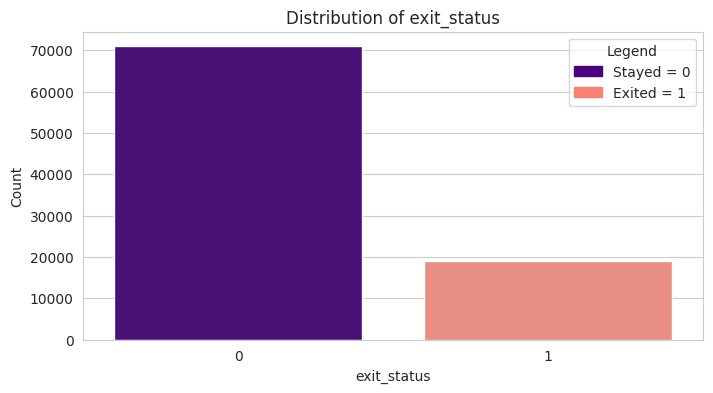

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(8,4))
sns.set_style("whitegrid")

ax = sns.countplot(data=train, x="exit_status", palette={0: "indigo", 1: "salmon"})
plt.title('Distribution of exit_status')
plt.ylabel('Count')
plt.xlabel('exit_status')

legend_handles = [
    Patch(color='indigo', label='Stayed = 0'),
    Patch(color='salmon', label='Exited = 1')
]
plt.legend(handles=legend_handles, title='Legend')
plt.show()

***Estimated Salary vs Exit_Status***

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_

<Figure size 800x400 with 0 Axes>

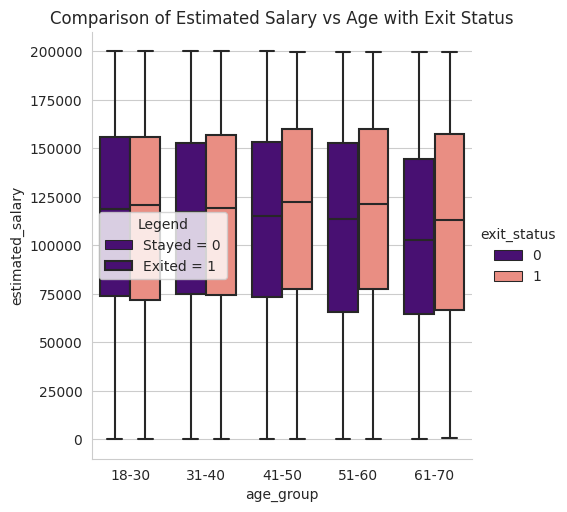

In [208]:
#estimated_salary vs "exit_status"
plt.figure(figsize=(8,4))
sns.set_style("whitegrid")

train['age_group'] = pd.cut(train['age'], bins=[18, 30, 40, 50, 60, 70], labels=['18-30', '31-40', '41-50', '51-60', '61-70'])

sns.catplot(data=train, x="age_group", y="estimated_salary", hue="exit_status", kind="box", palette={0: "indigo", 1: "salmon"})

plt.title('Comparison of Estimated Salary vs Age with Exit Status')
plt.ylabel('estimated_salary')
plt.xlabel('age_group')

plt.legend(title='Legend', labels=['Stayed = 0', 'Exited = 1'])
plt.show()

***Comparison of Product Count vs Balance in Account with Exit Status***

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_

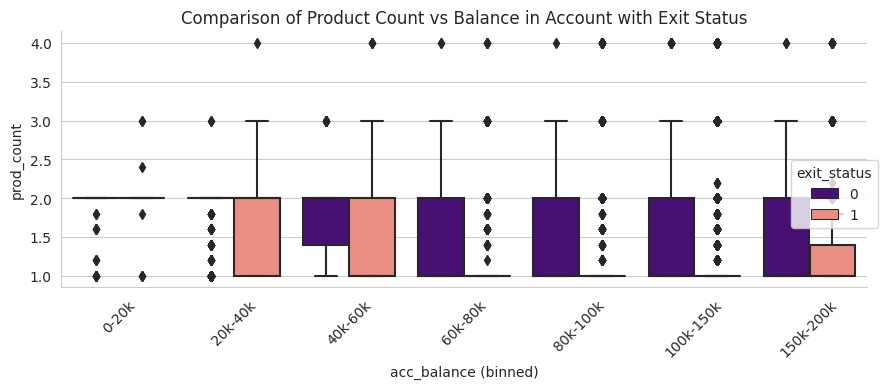

In [209]:
#acc_balance vs prod_count
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


bin_edges = [0, 20000, 40000, 60000, 80000, 100000, 150000, 200000]
bin_labels = ['0-20k', '20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k-150k', '150k-200k']
train['acc_balance_binned'] = pd.cut(train['acc_balance'], bins=bin_edges, labels=bin_labels)

g = sns.catplot(
    data=train,
    x="acc_balance_binned",
    y="prod_count",
    hue="exit_status",
    kind="box",
    palette={0: "indigo", 1: "salmon"},
    height=4,
    aspect=2
)

g.set(title='Comparison of Product Count vs Balance in Account with Exit Status')
g.set_axis_labels("acc_balance (binned)", "prod_count")


g._legend.set_title("exit_status")
g._legend.set_frame_on(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rubrics7: Scale Numerical features and Encode Categorical features
***Explanation for scaling (or not scaling) and encoding (or not encoding) is provided***

*We scale numerical features to ensure they are on the same scale, which helps models like logistic regression and KNN perform better. We one-hot encode categorical features so they can be represented numerically without implying any ordinal relationship. This preprocessing ensures all features are in a suitable format for training machine learning models.*

In [212]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
import tempfile

cachedir1 = tempfile.mkdtemp()

num_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'estimated_salary', 'has_card', 'is_active']
for col in ['credit_score', 'country', 'acc_balance', 'prod_count']:
    train[f'{col}_missing_indicator'] = train[col].isna().astype(int)
missing_indicator_cols = ['credit_score_missing_indicator', 'country_missing_indicator', 'acc_balance_missing_indicator', 'prod_count_missing_indicator']

cat_cols = ['country', 'gender']

# Numeric scaler
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# One-hot encoder with drop='if_binary'
OHE_cat_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

# Column transformer
preprocessor_OHE = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OHE_cat_transformer, cat_cols),
        ('missing_indicator', 'passthrough', missing_indicator_cols)
    ]
)

# Final preprocessing pipeline with VarianceThreshold
var_thresh_preprocessor_OHE = Pipeline(steps=[
    ('preprocessor', preprocessor_OHE),
    ('var_thresh', VarianceThreshold(threshold=0.0))
], memory=cachedir1)

# Store in dict
preprocessor_pipeline_dict = {
    'logistic_regression': var_thresh_preprocessor_OHE,
    'perceptron': var_thresh_preprocessor_OHE,
    'random_forest_classifier': var_thresh_preprocessor_OHE,
    'gradient_boosting_classifier': var_thresh_preprocessor_OHE,
    'ada_boost_classifier': var_thresh_preprocessor_OHE,
    'decision_tree_classifier': var_thresh_preprocessor_OHE,
    'knn_classifier': var_thresh_preprocessor_OHE,
}

# Rubrics8: Model Building (at least 7)
***7 different types of models are trained on the data***

*7 MODELS trained are:*
1. Logistic Regression
2. Perceptron
3. KNN
4. Decision Tree
5. Random Forest
6. Gradient Boosting
7. AdaBoost

In [213]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


X = train.drop(columns='exit_status')
y = train['exit_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Perceptron': Perceptron(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier()
}


trained_models = {}


for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_OHE),
        ('var_thresh', VarianceThreshold(threshold=0.0)),
        ('classifier', model)
    ])
    
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 40)
    
    trained_models[name] = pipeline


Training Logistic Regression...
--- Logistic Regression ---
Accuracy: 0.8311666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90     14209
           1       0.68      0.37      0.48      3791

    accuracy                           0.83     18000
   macro avg       0.77      0.66      0.69     18000
weighted avg       0.82      0.83      0.81     18000

----------------------------------------
Training Perceptron...
--- Perceptron ---
Accuracy: 0.7188333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81     14209
           1       0.37      0.48      0.42      3791

    accuracy                           0.72     18000
   macro avg       0.61      0.63      0.62     18000
weighted avg       0.75      0.72      0.73     18000

----------------------------------------
Training KNN...
--- KNN ---
Accuracy: 0.8411111111111111

# Rubrics9: Hyperparameter Tuning on any 3 of the models
***Hyperparameter tuning is done on 3 of the models***

In [215]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score


X = train.drop(columns='exit_status')
y = train['exit_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Logistic Regression ---
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor_OHE),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('classifier', LogisticRegression(max_iter=1000))
])

logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

logreg_grid = GridSearchCV(logreg_pipe, logreg_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
logreg_grid.fit(X_train, y_train)
print("Logistic Regression Best Params:", logreg_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, logreg_grid.predict(X_test)))

# --- Random Forest ---
rf_pipe = Pipeline([
    ('preprocessor', preprocessor_OHE),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Random Forest Best Params:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_grid.predict(X_test)))

# --- K-Nearest Neighbors ---
knn_pipe = Pipeline([
    ('preprocessor', preprocessor_OHE),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]  
}

knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
print("KNN Best Params:", knn_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, knn_grid.predict(X_test)))


Logistic Regression Best Params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Accuracy: 0.8308333333333333
Random Forest Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Accuracy: 0.8576666666666667
KNN Best Params: {'classifier__n_neighbors': 9, 'classifier__p': 2, 'classifier__weights': 'uniform'}
Accuracy: 0.8503888888888889


## Rubrics10: Comparison of model performances
***Performance of the models on validation set is compared***

In [218]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.feature_selection import VarianceThreshold

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Perceptron': Perceptron(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_OHE),
        ('var_thresh', VarianceThreshold(threshold=0.0)),
        ('classifier', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    })

import pandas as pd
performance_df = pd.DataFrame(results)
performance_df = performance_df.sort_values(by='F1-Score', ascending=False)
print(performance_df)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
3    Gradient Boosting  0.860667   0.744195  0.515695  0.609224  0.878343
4             AdaBoost  0.857611   0.732929  0.509628  0.601214  0.871855
2        Random Forest  0.855167   0.718128  0.514112  0.599231  0.864493
6                  KNN  0.841111   0.659582  0.507518  0.573643  0.813151
5        Decision Tree  0.789667   0.500633  0.521498  0.510853  0.691340
0  Logistic Regression  0.831167   0.682347  0.371142  0.480779  0.812486
1           Perceptron  0.718833   0.370725  0.480348  0.418476       NaN


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [219]:
performance_df = pd.DataFrame(results)

performance_df = performance_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print(performance_df)

best_model_name = performance_df.iloc[0]['Model']
print(f"Best model based on F1-Score: {best_model_name}")

best_model = models[best_model_name]
final_model = Pipeline([
    ('preprocessor', preprocessor_OHE),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('classifier', best_model)
])
final_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0    Gradient Boosting  0.860667   0.744195  0.515695  0.609224  0.878343
1             AdaBoost  0.857611   0.732929  0.509628  0.601214  0.871855
2        Random Forest  0.855167   0.718128  0.514112  0.599231  0.864493
3                  KNN  0.841111   0.659582  0.507518  0.573643  0.813151
4        Decision Tree  0.789667   0.500633  0.521498  0.510853  0.691340
5  Logistic Regression  0.831167   0.682347  0.371142  0.480779  0.812486
6           Perceptron  0.718833   0.370725  0.480348  0.418476       NaN
Best model based on F1-Score: Gradient Boosting


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score', 'age',
                                                   'tenure', 'acc_balance',
                                                   'prod_count',
                                                   'estimated_salary',
                                                   'has_card', 'is_active']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['country', 'gender']),
                                                 ('missing_indicator',
                                                  'passthrough',
                                                  ['credit_score_missing_indicator',
                                                   'country_missing_indicator',
                                                   'acc_balance_missing_indicator',
                                                   'prod_count_missing_indicator'])])),
                ('var_thresh', VarianceThreshold()),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [223]:
for col in ['credit_score', 'country', 'acc_balance', 'prod_count']:
    test[f'{col}_missing_indicator'] = test[col].isna().astype(int)
final_pred = final_model.predict(test)

submission_df = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv')
submission_df['exit_status'] = final_pred.astype(int)

submission_df.to_csv('submission.csv', index=False)
print("submission.csv generated successfully.")

submission.csv generated successfully.
